# Coleta e preparação de dados

In [243]:
import pandas as pd

In [244]:
df = pd.read_csv(r'C:\Users\Arthur Lindolpho\Documents\data_science_Alura\estilizacao de tabelas\relatorio_vendas.csv')

In [245]:
df.head()

,data_pedido,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,vendas,quantidade,lucro
0,2018-11-09,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,encanamentos,890.66,2,142.51
1,2018-11-09,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,ferramentas,2488.60,3,746.58
2,2018-06-13,Econômica,Giovanna Lima,B2B,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,sementes,49.71,2,23.36
3,2017-10-12,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Materiais de construção,materiais de revestimento,3255.76,5,-1302.31
4,2017-10-12,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Jardinagem e paisagismo,vasos,76.05,2,8.56


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_pedido       8940 non-null   object 
 1   modo_envio        8940 non-null   object 
 2   nome_cliente      8940 non-null   object 
 3   segmento_cliente  8940 non-null   object 
 4   cidade            8940 non-null   object 
 5   estado            8940 non-null   object 
 6   regiao            8940 non-null   object 
 7   departamento      8940 non-null   object 
 8   tipo_produto      8940 non-null   object 
 9   vendas            8940 non-null   float64
 10  quantidade        8940 non-null   int64  
 11  lucro             8940 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 838.3+ KB


In [247]:
df['data_pedido'] = pd.to_datetime(df['data_pedido'])

# Missão 1: Time de vendas

Precisamos construir uma visualização para indicar os **10 maiores clientes por total de venda**.

Com isso, a equipe de vendas pode pensar em estratégias para manter esses clientes comprando em nossa loja.

In [248]:
top10_clientes = df.groupby('nome_cliente')['vendas'].sum().sort_values(ascending=False).head(10)

In [249]:
top10_clientes = pd.DataFrame(top10_clientes)


In [250]:
top10_clientes = top10_clientes.reset_index()

In [251]:
top10_clientes

,nome_cliente,vendas
0,Maria Luiza Almeida,64777.54
1,Ana Julia Pinto,51398.95
2,Ryan Farias,48178.94
3,Heitor da Mata,47610.85
4,Maria Clara Gonçalves,46946.42
5,Raquel Freitas,44826.26
6,Davi Ramos,43769.21
7,Amanda Melo,42354.27
8,Alexia Ribeiro,41238.84
9,Calebe Ribeiro,41056.70


In [252]:
top10_clientes.columns = ['Clientes', 'Vendas']
top10_clientes['Rank'] = top10_clientes.index + 1
top10_clientes.set_index('Rank', inplace=True)

In [253]:
top10_clientes

,Clientes,Vendas
Rank,,
1,Maria Luiza Almeida,64777.54
2,Ana Julia Pinto,51398.95
3,Ryan Farias,48178.94
4,Heitor da Mata,47610.85
5,Maria Clara Gonçalves,46946.42
6,Raquel Freitas,44826.26
7,Davi Ramos,43769.21
8,Amanda Melo,42354.27
9,Alexia Ribeiro,41238.84


In [254]:
s = top10_clientes.style
s

,Clientes,Vendas
Rank,,
1,Maria Luiza Almeida,64777.540000
2,Ana Julia Pinto,51398.950000
3,Ryan Farias,48178.940000
4,Heitor da Mata,47610.850000
5,Maria Clara Gonçalves,46946.420000
6,Raquel Freitas,44826.260000
7,Davi Ramos,43769.210000
8,Amanda Melo,42354.270000
9,Alexia Ribeiro,41238.840000


In [255]:
s.format({'Vendas': 'R$ {:,.2f}'})
s

,Clientes,Vendas
Rank,,
1,Maria Luiza Almeida,"R$ 64,777.54"
2,Ana Julia Pinto,"R$ 51,398.95"
3,Ryan Farias,"R$ 48,178.94"
4,Heitor da Mata,"R$ 47,610.85"
5,Maria Clara Gonçalves,"R$ 46,946.42"
6,Raquel Freitas,"R$ 44,826.26"
7,Davi Ramos,"R$ 43,769.21"
8,Amanda Melo,"R$ 42,354.27"
9,Alexia Ribeiro,"R$ 41,238.84"


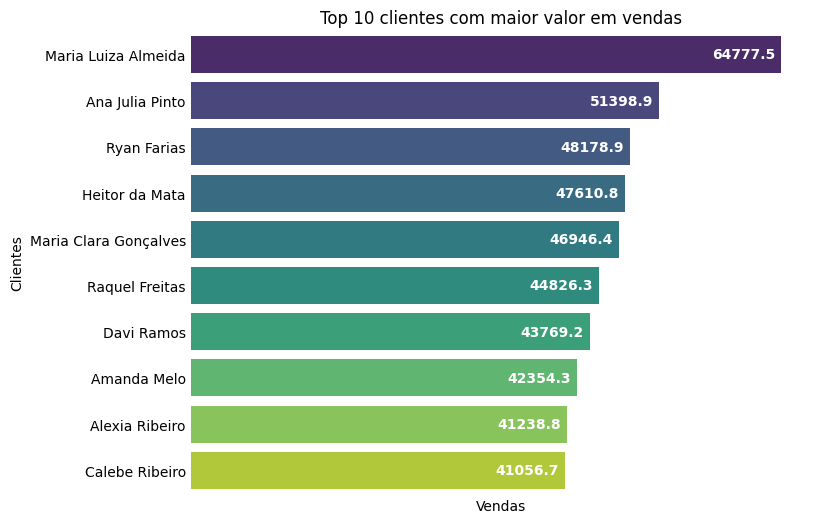

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize= (8,6))
sns.barplot(x = top10_clientes['Vendas'], y = top10_clientes['Clientes'], palette = 'viridis', hue = top10_clientes['Clientes'])
for container in ax.containers:
    ax.bar_label(container, padding = -50, color ='white', weight = 'bold')
ax.tick_params(axis = 'both', length = 0)
ax.set_xticks([])
ax.set_title('Top 10 clientes com maior valor em vendas')
plt.box(False)
plt.show()

# Missão 2: Time comercial

Precisamos construir uma visualização que permita associar o **total ganho em vendas e o total lucrado por tipo de produto**.

Isso vai permitir que o time comercial possa focar em estratégias para alavancar as rendas que ganham com cada tipo de produto vendido na loja.

In [257]:
df_vendas_lucro = df.groupby(['tipo_produto'])[['vendas', 'lucro']].sum()

In [258]:
df_vendas_lucro.index.name = 'tipo produto'

In [259]:
df_vendas_lucro

,vendas,lucro
tipo produto,,
decoração de jardim,82680.87,19880.86
encanamentos,373224.39,-11243.39
equipamentos de limpeza,542304.55,17448.30
ferramentas,995159.43,82042.91
ferramentas automotivas,502109.33,126660.54
ferramentas de jardinagem,648880.47,106408.80
fertilizantes,53144.55,22509.86
iluminação,275229.82,40531.09
materiais de paisagismo,150552.80,-3823.67


In [260]:
estilo_produto = df_vendas_lucro.style
estilo_produto

,vendas,lucro
tipo produto,,
decoração de jardim,82680.870000,19880.860000
encanamentos,373224.390000,-11243.390000
equipamentos de limpeza,542304.550000,17448.300000
ferramentas,995159.430000,82042.910000
ferramentas automotivas,502109.330000,126660.540000
ferramentas de jardinagem,648880.470000,106408.800000
fertilizantes,53144.550000,22509.860000
iluminação,275229.820000,40531.090000
materiais de paisagismo,150552.800000,-3823.670000


In [261]:
estilo_produto = estilo_produto.format({'vendas': 'R$ {:,.2f}', 'lucro': 'R$ {:,.2f}'})\
                .highlight_max(color='green')\
                .highlight_min(color = 'red')

estilo_produto

,vendas,lucro
tipo produto,,
decoração de jardim,"R$ 82,680.87","R$ 19,880.86"
encanamentos,"R$ 373,224.39","R$ -11,243.39"
equipamentos de limpeza,"R$ 542,304.55","R$ 17,448.30"
ferramentas,"R$ 995,159.43","R$ 82,042.91"
ferramentas automotivas,"R$ 502,109.33","R$ 126,660.54"
ferramentas de jardinagem,"R$ 648,880.47","R$ 106,408.80"
fertilizantes,"R$ 53,144.55","R$ 22,509.86"
iluminação,"R$ 275,229.82","R$ 40,531.09"
materiais de paisagismo,"R$ 150,552.80","R$ -3,823.67"


In [262]:
estilo_produto.format({'vendas': 'R$ {:,.2f}', 'lucro': 'R$ {:,.2f}'}).background_gradient(cmap='Greens')

,vendas,lucro
tipo produto,,
decoração de jardim,"R$ 82,680.87","R$ 19,880.86"
encanamentos,"R$ 373,224.39","R$ -11,243.39"
equipamentos de limpeza,"R$ 542,304.55","R$ 17,448.30"
ferramentas,"R$ 995,159.43","R$ 82,042.91"
ferramentas automotivas,"R$ 502,109.33","R$ 126,660.54"
ferramentas de jardinagem,"R$ 648,880.47","R$ 106,408.80"
fertilizantes,"R$ 53,144.55","R$ 22,509.86"
iluminação,"R$ 275,229.82","R$ 40,531.09"
materiais de paisagismo,"R$ 150,552.80","R$ -3,823.67"


In [263]:
cabecalho = {
    'selector' : 'th',
    'props' : 'font-weight: bold; font-family: Arial; text-align: center; text-transform: capitalize;'
}
estilo_produto.set_table_styles([cabecalho], overwrite=False)

,vendas,lucro
tipo produto,,
decoração de jardim,"R$ 82,680.87","R$ 19,880.86"
encanamentos,"R$ 373,224.39","R$ -11,243.39"
equipamentos de limpeza,"R$ 542,304.55","R$ 17,448.30"
ferramentas,"R$ 995,159.43","R$ 82,042.91"
ferramentas automotivas,"R$ 502,109.33","R$ 126,660.54"
ferramentas de jardinagem,"R$ 648,880.47","R$ 106,408.80"
fertilizantes,"R$ 53,144.55","R$ 22,509.86"
iluminação,"R$ 275,229.82","R$ 40,531.09"
materiais de paisagismo,"R$ 150,552.80","R$ -3,823.67"


# Missão 3: Time de logística

Precisamos construir uma visualização que permita entender a **distribuição de pedidos por região do Brasil**.

Isso vai permitir que o time logística entenda onde é mais interessante focar material e pessoas.

In [264]:
df_regiao = pd.DataFrame(df['regiao'].value_counts())
df_regiao.columns = ['N° de pedidos']
df_regiao.index.name = 'Região'
df_regiao

,N° de pedidos
Região,
Sudeste,4470
Nordeste,2075
Centro-Oeste,983
Norte,779
Sul,633


In [265]:
import numpy as np

In [266]:
total_pedidos = df_regiao['N° de pedidos'].sum()
df_regiao['Porcentagem %'] = (df_regiao['N° de pedidos']/total_pedidos) * 100

In [267]:
df_regiao

,N° de pedidos,Porcentagem %
Região,,
Sudeste,4470,50.000000
Nordeste,2075,23.210291
Centro-Oeste,983,10.995526
Norte,779,8.713647
Sul,633,7.080537


In [268]:
estilo_regiao = df_regiao.style
estilo_regiao

,N° de pedidos,Porcentagem %
Região,,
Sudeste,4470,50.000000
Nordeste,2075,23.210291
Centro-Oeste,983,10.995526
Norte,779,8.713647
Sul,633,7.080537


In [269]:
cabecalho = {
    'selector' : 'th',
    'props' : 'font-weight: bold; font-family: Arial; text-align: right; background-color: white'
}

celulas = {
    'selector': 'td',
    'props' : 'background-color: white;'
}

estilo_regiao.set_table_styles([cabecalho, celulas])

,N° de pedidos,Porcentagem %
Região,,
Sudeste,4470,50.000000
Nordeste,2075,23.210291
Centro-Oeste,983,10.995526
Norte,779,8.713647
Sul,633,7.080537


In [270]:
estilo_regiao.format({'Porcentagem %': '{:.2f} %'})\
                .bar(subset='Porcentagem %', vmin= 0, vmax=100, color = '#9CD33B')

,N° de pedidos,Porcentagem %
Região,,
Sudeste,4470,50.00 %
Nordeste,2075,23.21 %
Centro-Oeste,983,11.00 %
Norte,779,8.71 %
Sul,633,7.08 %


# Missão 4: Time de logística

Novamente o time de logística deseja repensar sua estrutura e organização de fornecimento de produtos e para isso, foi pensada em uma visualização que permita identificar padrão de **quantidade de produtos solicitados por mês por departamento**.

In [271]:
df_logistica = df.copy()

In [272]:
df_logistica.sort_values('data_pedido')

,data_pedido,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,vendas,quantidade,lucro
7171,2016-01-04,Entrega padrão,Ana Júlia Monteiro,B2C,Belo Horizonte,Minas Gerais,Sudeste,Jardinagem e paisagismo,pesticidas,55.92,2,18.87
651,2016-01-05,Entrega padrão,Maria Cecília Jesus,B2B,Botucatu,São Paulo,Sudeste,Jardinagem e paisagismo,ferramentas de jardinagem,12.04,2,-18.66
650,2016-01-05,Entrega padrão,Maria Cecília Jesus,B2B,Botucatu,São Paulo,Sudeste,Jardinagem e paisagismo,vasos,927.30,3,-220.23
649,2016-01-05,Entrega padrão,Maria Cecília Jesus,B2B,Botucatu,São Paulo,Sudeste,Jardinagem e paisagismo,sementes,40.07,3,14.52
1576,2016-01-06,Entrega padrão,Marcelo Rezende,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,decoração de jardim,66.42,3,16.61
...,...,...,...,...,...,...,...,...,...,...,...,...
796,2019-12-31,Entrega padrão,Lara Pinto,B2C,São Paulo,São Paulo,Sudeste,Jardinagem e paisagismo,ferramentas de jardinagem,179.44,3,67.29
795,2019-12-31,Entrega padrão,Lara Pinto,B2C,São Paulo,São Paulo,Sudeste,Automotivo,pneus,309.16,7,9.27
794,2019-12-31,Entrega padrão,Lara Pinto,B2C,São Paulo,São Paulo,Sudeste,Materiais de construção,encanamentos,1098.66,4,41.20
1151,2019-12-31,Entrega padrão,Cauê Martins,B2B,Osasco,São Paulo,Sudeste,Jardinagem e paisagismo,ferramentas de jardinagem,47.27,2,15.36


In [273]:
df_logistica['meses'] = df_logistica['data_pedido'].dt.strftime('%Y - %b')
df_logistica = df_logistica.reset_index(drop=True)

In [274]:
df_logistica

,data_pedido,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,vendas,quantidade,lucro,meses
0,2018-11-09,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,encanamentos,890.66,2,142.51,2018 - Nov
1,2018-11-09,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,ferramentas,2488.60,3,746.58,2018 - Nov
2,2018-06-13,Econômica,Giovanna Lima,B2B,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,sementes,49.71,2,23.36,2018 - Jun
3,2017-10-12,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Materiais de construção,materiais de revestimento,3255.76,5,-1302.31,2017 - Oct
4,2017-10-12,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Jardinagem e paisagismo,vasos,76.05,2,8.56,2017 - Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8935,2018-09-30,Entrega padrão,Enrique Santos,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Automotivo,ferramentas automotivas,123.22,1,51.75,2018 - Sep
8936,2019-11-18,Entrega padrão,Heitor Silveira,B2B,Jequié,Bahia,Nordeste,Automotivo,ferramentas automotivas,271.97,1,97.91,2019 - Nov
8937,2019-11-18,Entrega padrão,Heitor Silveira,B2B,Jequié,Bahia,Nordeste,Automotivo,pneus,700.74,5,189.20,2019 - Nov
8938,2016-01-22,Econômica,Isabel Araújo,B2C,João Pessoa,Paraíba,Nordeste,Materiais de construção,iluminação,85.84,3,13.95,2016 - Jan


In [275]:
vendas_mensais = df_logistica.pivot_table(index = 'departamento', columns='meses', values = 'quantidade', aggfunc='sum', sort=False)

vendas_mensais

meses,2018 - Nov,2018 - Jun,2017 - Oct,2016 - Jun,2019 - Apr,2018 - Dec,2017 - Nov,2016 - Nov,2016 - Aug,2019 - Jul,...,2017 - Jul,2016 - Jul,2016 - Apr,2019 - Mar,2019 - Aug,2019 - Jan,2016 - Feb,2016 - May,2016 - Jan,2018 - Feb
departamento,,,,,,,,,,,,,,,,,,,,,
Materiais de construção,308,117,129,114,131,294,259,213,101,162,...,128,104,69,107,132,83,23,91,60,67
Jardinagem e paisagismo,727,473,260,273,415,770,746,716,339,423,...,268,348,323,458,561,361,87,270,161,177
Automotivo,253,118,100,83,87,189,179,236,95,168,...,88,91,107,167,136,109,20,81,45,49


In [276]:
estilo_mensal = vendas_mensais.style
estilo_mensal

meses,2018 - Nov,2018 - Jun,2017 - Oct,2016 - Jun,2019 - Apr,2018 - Dec,2017 - Nov,2016 - Nov,2016 - Aug,2019 - Jul,2017 - Sep,2018 - Jan,2019 - Oct,2017 - Dec,2019 - Sep,2018 - Jul,2018 - Mar,2016 - Oct,2017 - May,2016 - Dec,2018 - Sep,2017 - Apr,2019 - Dec,2019 - Nov,2019 - May,2018 - Apr,2017 - Feb,2019 - Jun,2018 - Aug,2017 - Mar,2016 - Sep,2019 - Feb,2018 - Oct,2017 - Jun,2016 - Mar,2018 - May,2017 - Jan,2017 - Aug,2017 - Jul,2016 - Jul,2016 - Apr,2019 - Mar,2019 - Aug,2019 - Jan,2016 - Feb,2016 - May,2016 - Jan,2018 - Feb
departamento,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Materiais de construção,308,117,129,114,131,294,259,213,101,162,194,91,213,258,282,132,127,94,76,269,227,85,395,312,172,128,38,151,113,100,182,67,171,120,102,171,93,106,128,104,69,107,132,83,23,91,60,67
Jardinagem e paisagismo,727,473,260,273,415,770,746,716,339,423,663,190,617,628,929,413,260,276,269,525,757,271,989,946,542,338,131,490,380,278,549,205,402,321,277,463,97,322,268,348,323,458,561,361,87,270,161,177
Automotivo,253,118,100,83,87,189,179,236,95,168,180,59,205,235,280,117,112,85,94,154,181,111,252,331,150,72,44,170,123,74,154,63,103,59,46,124,55,117,88,91,107,167,136,109,20,81,45,49


In [277]:
estilo_mensal.set_sticky(axis='index')

meses,2018 - Nov,2018 - Jun,2017 - Oct,2016 - Jun,2019 - Apr,2018 - Dec,2017 - Nov,2016 - Nov,2016 - Aug,2019 - Jul,2017 - Sep,2018 - Jan,2019 - Oct,2017 - Dec,2019 - Sep,2018 - Jul,2018 - Mar,2016 - Oct,2017 - May,2016 - Dec,2018 - Sep,2017 - Apr,2019 - Dec,2019 - Nov,2019 - May,2018 - Apr,2017 - Feb,2019 - Jun,2018 - Aug,2017 - Mar,2016 - Sep,2019 - Feb,2018 - Oct,2017 - Jun,2016 - Mar,2018 - May,2017 - Jan,2017 - Aug,2017 - Jul,2016 - Jul,2016 - Apr,2019 - Mar,2019 - Aug,2019 - Jan,2016 - Feb,2016 - May,2016 - Jan,2018 - Feb
departamento,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Materiais de construção,308,117,129,114,131,294,259,213,101,162,194,91,213,258,282,132,127,94,76,269,227,85,395,312,172,128,38,151,113,100,182,67,171,120,102,171,93,106,128,104,69,107,132,83,23,91,60,67
Jardinagem e paisagismo,727,473,260,273,415,770,746,716,339,423,663,190,617,628,929,413,260,276,269,525,757,271,989,946,542,338,131,490,380,278,549,205,402,321,277,463,97,322,268,348,323,458,561,361,87,270,161,177
Automotivo,253,118,100,83,87,189,179,236,95,168,180,59,205,235,280,117,112,85,94,154,181,111,252,331,150,72,44,170,123,74,154,63,103,59,46,124,55,117,88,91,107,167,136,109,20,81,45,49


In [278]:
colunas = {
    'selector': '.col_heading',
    'props': 'font-weight: normal; font-family: Arial'
}

tabelas = {
    'selector': 'td, th',
    'props': 'text-align: left;'
}
index = {
    'selector': '.index_name',
    'props': 'font-weight: bold; font-family: Arial; text-align: right;'
}

estilo_mensal.set_table_styles([colunas, tabelas, index], overwrite=False)

meses,2018 - Nov,2018 - Jun,2017 - Oct,2016 - Jun,2019 - Apr,2018 - Dec,2017 - Nov,2016 - Nov,2016 - Aug,2019 - Jul,2017 - Sep,2018 - Jan,2019 - Oct,2017 - Dec,2019 - Sep,2018 - Jul,2018 - Mar,2016 - Oct,2017 - May,2016 - Dec,2018 - Sep,2017 - Apr,2019 - Dec,2019 - Nov,2019 - May,2018 - Apr,2017 - Feb,2019 - Jun,2018 - Aug,2017 - Mar,2016 - Sep,2019 - Feb,2018 - Oct,2017 - Jun,2016 - Mar,2018 - May,2017 - Jan,2017 - Aug,2017 - Jul,2016 - Jul,2016 - Apr,2019 - Mar,2019 - Aug,2019 - Jan,2016 - Feb,2016 - May,2016 - Jan,2018 - Feb
departamento,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Materiais de construção,308,117,129,114,131,294,259,213,101,162,194,91,213,258,282,132,127,94,76,269,227,85,395,312,172,128,38,151,113,100,182,67,171,120,102,171,93,106,128,104,69,107,132,83,23,91,60,67
Jardinagem e paisagismo,727,473,260,273,415,770,746,716,339,423,663,190,617,628,929,413,260,276,269,525,757,271,989,946,542,338,131,490,380,278,549,205,402,321,277,463,97,322,268,348,323,458,561,361,87,270,161,177
Automotivo,253,118,100,83,87,189,179,236,95,168,180,59,205,235,280,117,112,85,94,154,181,111,252,331,150,72,44,170,123,74,154,63,103,59,46,124,55,117,88,91,107,167,136,109,20,81,45,49


# Missão 5: Relatório de performance

O relatório de performance é um documento muito importante para a empresa. Nele, todos que trabalham na loja podem entender como anda a empresa. Por conta disso, tabelas bem construídas são essenciais para mostrar os dados da melhor forma.

Portanto, precisamos construir uma visualização que permita entender a **relação entre tipos de clientes e modo de envio de produtos de acordo com as vendas**. Com isso, será possível destacar no relatório qual o modo de envio e quais tipos de modo de envio mais geraram ganho em vendas.

In [279]:
df_cliente = df.pivot_table(index='segmento_cliente', columns='modo_envio', values='vendas', aggfunc='sum')
df_cliente

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido
segmento_cliente,,,,
B2B,217466.05,718462.52,1884740.78,602049.56
B2C,182531.80,729176.13,2248286.96,498295.55


In [280]:
df_cliente['Total'] = df_cliente.sum(axis = 1)
df_cliente.loc['Total'] = df_cliente.sum()
df_cliente

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido,Total
segmento_cliente,,,,,
B2B,217466.05,718462.52,1884740.78,602049.56,3422718.91
B2C,182531.80,729176.13,2248286.96,498295.55,3658290.44
Total,399997.85,1447638.65,4133027.74,1100345.11,7081009.35


In [282]:
compra_cliente = df_cliente.style.format('{:,.2f}')
compra_cliente

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido,Total
segmento_cliente,,,,,
B2B,"217,466.05","718,462.52","1,884,740.78","602,049.56","3,422,718.91"
B2C,"182,531.80","729,176.13","2,248,286.96","498,295.55","3,658,290.44"
Total,"399,997.85","1,447,638.65","4,133,027.74","1,100,345.11","7,081,009.35"


In [283]:
tabela = {
    'selector': 'td, th:not(.index_name)',
    'props': 'font-weight: normal; font-family: Arial; text-align: center; background-color: white'
}

index = {
    'selector': '.index_name',
    'props': 'font-weight: normal; text-align: right; font-style: italic; color: #696969'
}
compra_cliente.set_table_styles([tabela, index])

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido,Total
segmento_cliente,,,,,
B2B,"217,466.05","718,462.52","1,884,740.78","602,049.56","3,422,718.91"
B2C,"182,531.80","729,176.13","2,248,286.96","498,295.55","3,658,290.44"
Total,"399,997.85","1,447,638.65","4,133,027.74","1,100,345.11","7,081,009.35"


In [284]:
compra_cliente.set_table_styles({'Total': [{
    'selector': 'th',
    'props': 'border-top: 1px solid #181818'
},
{
    'selector': 'td',
    'props': 'border-top: 1px solid #181818'
}],
'B2B': [{
    'selector': 'th',
    'props': 'border-top: 1px solid #181818'
},
{
    'selector': 'td',
    'props': 'border-top: 1px solid #181818'
}]
}, overwrite=False, axis = 1)

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido,Total
segmento_cliente,,,,,
B2B,"217,466.05","718,462.52","1,884,740.78","602,049.56","3,422,718.91"
B2C,"182,531.80","729,176.13","2,248,286.96","498,295.55","3,658,290.44"
Total,"399,997.85","1,447,638.65","4,133,027.74","1,100,345.11","7,081,009.35"


In [285]:
compra_cliente.set_table_styles({
    'Total': [{
        'selector' : '.true',
        'props': 'background-color: #D8D8D8'
    }]
},overwrite=False, axis = 0)

cores_coluna = pd.DataFrame(['false', 'true', 'false'], index = df_cliente['Total'].index, columns=['Total'])

compra_cliente.set_td_classes(cores_coluna)

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido,Total
segmento_cliente,,,,,
B2B,"217,466.05","718,462.52","1,884,740.78","602,049.56","3,422,718.91"
B2C,"182,531.80","729,176.13","2,248,286.96","498,295.55","3,658,290.44"
Total,"399,997.85","1,447,638.65","4,133,027.74","1,100,345.11","7,081,009.35"
